# Reference tracking with ergodic exploration: the 2-DoF key-in-lock toy

The lock, the cloud and the E2T2 law of `Ergodic_Exploration_phase_key_in_lock_2D.ipynb`, with the tracking
scheme of Xu et al., "Ergodic Imitation for Adaptive Exploration around Demonstrations" (arXiv 2605.13996):

- a **reference clock** $\tau$ runs along the master at the speed the robot reaches in free motion;
- the **robot's phase** $\varphi_r$ is the phase of the master sample nearest to it, with no window and no latch;
- the **phase error** is $e = \tau - \varphi_r$. While $e \le \epsilon$ the clock runs; beyond it the clock waits
  and a **stall counter** $c$ counts;
- the **target** goes from the master at $\tau$ to the exploration cloud around $\tau$ as $c$ grows.

In place of the paper's anisotropic diffusion, the exploration target is the taught cloud, and what spreads with
the stall is its phase kernel behind $\tau$: earlier-phase datapoints return. The **step-back** is added on top: a
clock the robot has fallen well behind for a full stall time is set back to the robot.

Nothing is tuned. Section 3 lists every number and where it comes from.

In [1]:
import math
from dataclasses import dataclass

import numpy as np
from matplotlib import pyplot as plt

## 1. The E2T2 law, unchanged

$b_i = \sum_{\mathbf k} \Lambda_{\mathbf k} (\mathcal W_{\mathbf k} - \hat{\mathcal W}_{\mathbf k}) \nabla_i \Phi_{\mathbf k}(z)$,
$u = -u_{\max}\, b / \|b\|$, as in the phase notebook.

In [2]:
def basis(z, K):  # (M,) -> (M, K)
    return np.cos(np.pi * np.outer(z, np.arange(K)))


def basis_derivative(z, K):  # (M,) -> (M, K)
    k = np.arange(K)
    return -np.pi * k * np.sin(np.pi * np.outer(z, k))


def optimisation_weights(K, d=2):  # (K, K)
    k = np.arange(K)
    return (1.0 + k[:, None] ** 2 + k[None, :] ** 2) ** (-(d + 1) / 2)


def pull2centre(z, alpha=20.0, c=1.0 / 20):
    weight = np.tanh(alpha * (z - c)) / 2 + np.tanh(alpha * (1 - c - z)) / 2
    dz = -np.tanh(alpha * (z - c)) / 2 + np.tanh(alpha * (1 - c - z)) / 2
    return weight, dz


def ergodic_direction(z, D, lam):
    """E2T2's step direction at cube state z (2,), D = W - W_hat (K, K): unit length."""
    K = D.shape[0]
    phi_x, phi_t = basis(z[:1], K)[0], basis(z[1:], K)[0]
    dphi_x, dphi_t = basis_derivative(z[:1], K)[0], basis_derivative(z[1:], K)[0]
    LD = lam * D
    b = np.array([dphi_x @ LD @ phi_t, phi_x @ LD @ dphi_t])
    u = -b / (np.linalg.norm(b) + 1e-10)
    weight, centre = pull2centre(z)
    centre = centre / (np.linalg.norm(centre) + 1e-8)
    u = u * weight + centre * (1 - weight)
    return u / (np.linalg.norm(u) + 1e-8)


# Gradient check: phi'(z) against a central difference of phi(z).
_z, _eps = np.array([0.137, 0.71]), 1e-6
_fd = (basis(_z + _eps, 12) - basis(_z - _eps, 12)) / (2 * _eps)
print("max |dphi - finite difference|:", np.abs(basis_derivative(_z, 12) - _fd).max())
assert np.allclose(basis_derivative(_z, 12), _fd, atol=1e-6)

max |dphi - finite difference|: 7.01666635904985e-09


## 2. World, cloud and master

As the phase notebook, except that the master's phase is its **normalised arc length**: 8 scaled units of
insertion, then 9 of turning, so $\varphi = 8/17$ at the corner. Equal phase is equal travel, which is what the
clock's speed assumes.

In [3]:
THETA_SCALE = 10.0  # degrees per scaled unit


def metric(x, theta_deg):  # world (x, deg) -> scaled s, (..., 2)
    return np.stack(np.broadcast_arrays(x, np.asarray(theta_deg) / THETA_SCALE), axis=-1)


S_LO = np.array([-1.5, -5.5])  # scaled box of the cube
S_SPAN = 19.0


def to_cube(s):
    return (s - S_LO) / S_SPAN


def lcg(seed, a, c, m):
    """The prototype's generator, in doubles as JavaScript computes it."""
    state = float(seed)

    def draw():
        nonlocal state
        state = (state * a + c) % m
        return state / m

    return draw


def gauss(rnd):
    u = rnd() or 1e-9
    v = rnd()
    return math.sqrt(-2 * math.log(u)) * math.cos(2 * math.pi * v)


def make_cloud():  # (800, 2) scaled
    rnd = lcg(7, 1664525.0, 1013904223.0, 4294967296.0)
    points = []
    for _ in range(500):  # insertion
        p = -0.03 + rnd() * 0.53
        x = 16 * p + gauss(rnd) * 0.3
        points.append((x, min(35.0, max(-35.0, gauss(rnd) * 14))))
    for _ in range(260):  # turning
        x = min(8.25, 8 + gauss(rnd) * 0.15)
        points.append((x, rnd() * 102 + gauss(rnd) * 6))
    for _ in range(40):  # demonstration end states: where phi = 1 is
        x = 8 - abs(gauss(rnd)) * 0.05
        points.append((x, 90 + gauss(rnd) * 1.5))
    points = np.array(points)
    return metric(points[:, 0], points[:, 1])


LENGTH = 8.0 + 9.0  # scaled units: the insertion, then a 90 deg turn
PHI_GRID = np.linspace(0.0, 1.0, 401)


def master_path(phi):  # (M,) -> (M, 2) scaled
    a = np.atleast_1d(phi) * LENGTH
    return np.column_stack([np.minimum(a, 8.0), np.maximum(a - 8.0, 0.0)])


MASTER = master_path(PHI_GRID)


def project(s):
    """Phase of the master sample nearest to s (..., 2): where on the task the state is."""
    d = ((MASTER - np.asarray(s)[..., None, :]) ** 2).sum(axis=-1)
    return PHI_GRID[np.argmin(d, axis=-1)]


CLOUD = make_cloud()
PHI_CLOUD = project(CLOUD)
# Arc length: the samples are equally spaced, but for the one chord that cuts the corner.
_steps = np.linalg.norm(np.diff(MASTER, axis=0), axis=1)
assert np.isclose(_steps, LENGTH / 400).sum() == 399 and LENGTH - _steps.sum() < LENGTH / 400

## 3. Every number, and where it comes from

| quantity | value | source |
|---|---|---|
| $h$ | median distance to the $k$-th nearest cloud point, $k = \mathrm{round}(\sqrt N)$ | the cloud |
| $\sigma_f = h / \ell$ | the cloud's resolution as a phase | the cloud and the master's length $\ell$ |
| $v_\text{ref}$ | mean progress per step along the commanded direction | the actuator model, measured below |
| $\dot\tau = v_\text{ref} / \ell$ | clock phase per step | $v_\text{ref}$ |
| $\epsilon = \sigma_f$ | phase error the clock tolerates | the cloud's resolution |
| $T = \sigma_f / \dot\tau$ | steps the reference takes over one $\sigma_f$: the stall time scale | the two above |

The clock must run at a speed the robot can reach. Commanded at $v_{\max}$, with the actuator noise and the
speed cap, the robot makes less than half of $v_{\max}$ along its commanded direction. A clock at $v_{\max}$
would call every step of free motion a stall.

Left as chosen: $K = 10$ Fourier modes, memory every third step, and the factor 2 in the step-back (Section 5).

In [4]:
V_MAX = 0.07  # scaled units per step
NOISE = 0.25  # actuator noise is uniform in +-NOISE/2 per axis

_k = round(math.sqrt(len(CLOUD)))
_pairwise = np.hypot(*(CLOUD[:, None, :] - CLOUD[None, :, :]).transpose(2, 0, 1))
np.fill_diagonal(_pairwise, np.inf)
H = np.median(np.sort(_pairwise, axis=1)[:, _k - 1])
SIGMA_F = H / LENGTH
K = 10
LAMBDA = optimisation_weights(K)


def free_speed(n=200_000):
    """Mean progress per step along the commanded direction, under the actuator model of Run.step."""
    rng = np.random.default_rng(0)
    angle = rng.uniform(0, 2 * np.pi, n)
    d = np.column_stack([np.cos(angle), np.sin(angle)])
    u = V_MAX * d + (rng.uniform(size=(n, 2)) - 0.5) * NOISE
    speed = np.hypot(*u.T)
    u = np.where((speed > V_MAX)[:, None], u * (V_MAX / speed)[:, None], u)
    return float((u * d).sum(axis=1).mean())


V_REF = free_speed()
D_TAU = V_REF / LENGTH
EPS = SIGMA_F
T_STALL = SIGMA_F / D_TAU

print(f"h = {H:.4f} scaled units, sigma_f = eps = {SIGMA_F:.4f}")
print(f"v_ref = {V_REF:.4f} per step = {V_REF / V_MAX:.2f} v_max, clock {D_TAU:.5f} phase per step")
print(f"T = {T_STALL:.1f} steps")

h = 0.7500 scaled units, sigma_f = eps = 0.0441
v_ref = 0.0334 per step = 0.48 v_max, clock 0.00196 phase per step
T = 22.5 steps


## 4. Lock physics

The phase notebook's, with its false keyway: a second keyway that takes the key and holds $\theta$ but ends at
$x = 6$, short of where the key can turn.

In [5]:
FACE, DEPTH = 3.0, 8.0
TURN_DEPTH = DEPTH - 0.2  # the key can turn from here
FALSE_DEPTH = 6.0  # where the false keyway ends, short of TURN_DEPTH
KEYWAY_TOL = 4.0 / THETA_SCALE
TURNED = 0.5 / THETA_SCALE  # beyond this the key is held in
JAM_RELEASE = FACE - 0.12
SUCCESS_TURN = 89.0 / THETA_SCALE
THETA_LIMITS = (-5.0, 13.0)  # scaled


@dataclass
class Lock:
    kt: float  # keyway angle, scaled
    inside: bool = False
    jam: bool = False
    false_kt: float | None = None  # a second keyway's angle, scaled: a dead end
    in_false: bool = False


def _inside_step(lock, s, nx, nt):
    if s[0] < TURN_DEPTH:
        nt = lock.kt
    else:
        nt = max(lock.kt, nt)
        if nt > lock.kt + TURNED:
            nx = max(nx, TURN_DEPTH)
    nx = min(DEPTH, nx)
    if nx < FACE:
        if nt <= lock.kt + TURNED:
            lock.inside = False
        else:
            nx = FACE + 0.01
    return nx, nt


def _false_step(lock, s, nx, nt):
    """In the false keyway: theta held as in the true one, but it ends at FALSE_DEPTH."""
    lock.in_false = nx >= FACE
    return min(FALSE_DEPTH, nx), lock.false_kt


def _outside_step(lock, s, nx, nt):
    if lock.jam and s[0] > JAM_RELEASE:
        nt = s[1]
    if nx >= FACE:
        if abs(nt - lock.kt) < KEYWAY_TOL:
            lock.inside, lock.jam = True, False
            nt, nx = lock.kt, min(nx, DEPTH)
        elif lock.false_kt is not None and abs(nt - lock.false_kt) < KEYWAY_TOL:
            lock.in_false, lock.jam = True, False
            nt, nx = lock.false_kt, min(nx, FALSE_DEPTH)
        else:
            nx, lock.jam = FACE, True
    if lock.jam and nx < JAM_RELEASE:
        lock.jam = False
    return nx, nt


def lock_step(lock, s, s_new):
    """The pose the lock lets the robot reach from s when it commands s_new."""
    step = _inside_step if lock.inside else _false_step if lock.in_false else _outside_step
    nx, nt = step(lock, s, s_new[0], s_new[1])
    return np.array([nx, min(THETA_LIMITS[1], max(THETA_LIMITS[0], nt))])


# Small tests of the pure functions.
_lock = Lock(kt=metric(0, 14.0)[1])
assert lock_step(_lock, np.array([2.95, 0.0]), np.array([3.02, 0.0]))[0] == FACE and _lock.jam
assert (
    lock_step(_lock, np.array([2.95, 0.0]), np.array([2.97, 0.5]))[1] == 0.0
)  # jammed: theta frozen
_lock = Lock(kt=1.4)
assert lock_step(_lock, np.array([2.95, 1.4]), np.array([3.02, 1.5]))[1] == 1.4 and _lock.inside
_lock = Lock(kt=1.4, inside=True)
assert (
    lock_step(_lock, np.array([7.9, 3.0]), np.array([7.0, 3.0]))[0] == TURN_DEPTH
)  # turned: held in
_lock = Lock(kt=1.4, false_kt=0.0)
_s = lock_step(_lock, np.array([2.95, 0.1]), np.array([3.05, 0.1]))
assert _lock.in_false and not _lock.inside and _s[1] == 0.0
_s = lock_step(_lock, _s, np.array([9.0, 2.0]))  # false keyway: stopped at its end, no turning
assert tuple(_s) == (FALSE_DEPTH, 0.0)
_s = lock_step(_lock, _s, np.array([2.9, 0.3]))  # and free again once back out past the face
assert not _lock.in_false and tuple(_s) == (2.9, 0.0)
print("physics tests passed")

physics tests passed


## 5. The law

**Clock.** With $e = \tau - \varphi_r$:

- $e \le \epsilon$: the clock runs, $\tau \leftarrow \max(\tau + \dot\tau,\ \varphi_r)$. It is never behind the robot.
- $e > \epsilon$, or $\tau = 1$: the clock waits.
- $c$ is the number of steps since the clock last advanced. At the end of the master the clock cannot advance,
  so the robot explores around the end until the task is done.

**Target.** With $\theta = \min(1, c / T)$:

$$\hat{\mathcal W} = (1 - \theta) \sum_i m_i\, \Phi(z^\text{master}_i) + \theta \sum_j w_j\, \Phi(z^\text{cloud}_j)$$

- $m_i \propto \exp(-(\varphi_i - \tau)^2 / 2\sigma_f^2)$: the master around the clock. The clock is up to $\epsilon$
  ahead of the robot, which is the forward pull.
- $w_j$: the cloud around $\tau$, of width $\sigma_f$ ahead and $\sigma_b = \sigma_f (1 + c / T)$ behind. This is the
  diffusion: it has no ceiling.

**Statistic.** Every third state is stored with the clock's phase at the time. At clock $\tau$ a stored state
weighs $\exp(-(\tau_m - \tau)^2 / 2\sigma_f^2)$, and the statistic has mass 1.

**Step-back.** When $c \ge T$ and $e > 2\epsilon$, then $\tau \leftarrow \varphi_r$ and $c \leftarrow 0$. A stalled
clock sits $\epsilon$ ahead of where the robot stalled, so $e > 2\epsilon$ is the robot more than $\epsilon$ behind
that place.

`dwell_stall` is one variant, off by default: $c$ is not the clock's count but the time already spent at this
clock phase beyond what the reference spends there, $\sum_m 3 \exp(-(\tau_m - \tau)^2 / 2\sigma_f^2) - \sqrt{2\pi}\, T$.
It carries over a step-back and over a second visit, where the clock's count starts again from 0.

In [6]:
MEMORY_EVERY = 3
STEPS = 5000


def kernel(d, sigma_ahead, sigma_behind):  # (M,) phase differences -> (M,) weights of mass 1
    w = np.exp(-(d**2) / (2 * np.where(d > 0, sigma_ahead, sigma_behind) ** 2))
    return w / w.sum()


def coefficients(z, a):  # (M, 2) cube states, (M,) weights -> (K, K)
    return (basis(z[:, 0], K) * a[:, None]).T @ basis(z[:, 1], K)


@dataclass
class Clock:
    tau: float = 0.0
    c: int = 0  # steps since the clock last advanced


class Run:
    """One episode: the robot, the lock, the reference clock and the law."""

    step_back = True
    dwell_stall = False

    def __init__(self, kappa, seed=3, false_kappa=None):
        self.lock = Lock(kt=float(metric(0.0, kappa)[1]))
        if false_kappa is not None:
            self.lock.false_kt = float(metric(0.0, false_kappa)[1])
        self.noise = lcg(seed, 1103515245.0, 12345.0, 2147483648.0)
        self.s, self.clock = np.array([-0.6, 0.0]), Clock()
        self.memory, self.log = [], []  # (x, theta, tau) and (x, theta, phi_r, tau, stall / T, share)
        self.n, self.done, self.false_entries, self.step_backs = 0, False, 0, 0

    def memory_weights(self):  # (rows,)
        tau_m = np.array(self.memory)[:, 2]
        return np.exp(-((tau_m - self.clock.tau) ** 2) / (2 * SIGMA_F**2))

    def stall(self):
        """Steps stalled at this clock phase."""
        if not self.dwell_stall or not self.memory:
            return self.clock.c
        spent = MEMORY_EVERY * self.memory_weights().sum()
        return max(0.0, spent - math.sqrt(2 * math.pi) * T_STALL)

    def target(self):  # (K, K), and the cloud's share of it
        stall = self.stall() / T_STALL
        share = min(1.0, stall)
        m = kernel(PHI_GRID - self.clock.tau, SIGMA_F, SIGMA_F)
        w = kernel(PHI_CLOUD - self.clock.tau, SIGMA_F, SIGMA_F * (1 + stall))
        W_hat = (1 - share) * coefficients(to_cube(MASTER), m) + share * coefficients(to_cube(CLOUD), w)
        return W_hat, share

    def statistic(self):  # (K, K), of mass 1; empty before any stored state counts here
        if not self.memory:
            return np.zeros((K, K))
        v = self.memory_weights()
        if v.sum() < 1e-12:
            return np.zeros((K, K))
        return coefficients(to_cube(np.array(self.memory)[:, :2]), v / v.sum())

    def advance_clock(self, phi_r):
        clock = self.clock
        tau = clock.tau
        if clock.tau - phi_r <= EPS:
            tau = min(1.0, max(clock.tau + D_TAU, phi_r))
        clock.c = 0 if tau > clock.tau else clock.c + 1
        clock.tau = tau

    def step(self):
        clock = self.clock
        W_hat, share = self.target()
        u = V_MAX * ergodic_direction(to_cube(self.s), self.statistic() - W_hat, LAMBDA)
        u = u + (np.array([self.noise(), self.noise()]) - 0.5) * NOISE
        speed = np.hypot(*u)
        u = u * V_MAX / speed if speed > V_MAX else u
        in_false = self.lock.in_false
        self.s = lock_step(self.lock, self.s, self.s + u)
        self.false_entries += self.lock.in_false and not in_false
        phi_r = float(project(self.s))
        self.advance_clock(phi_r)
        if self.n % MEMORY_EVERY == 0:
            self.memory.append((*self.s, clock.tau))
        self.log.append((*self.s, phi_r, clock.tau, self.stall() / T_STALL, share))
        if self.step_back and self.stall() >= T_STALL and clock.tau - phi_r > 2 * EPS:
            clock.tau, clock.c = phi_r, 0
            self.step_backs += 1
        self.n += 1
        self.done = self.lock.inside and self.s[1] >= self.lock.kt + SUCCESS_TURN

    def run(self):
        while not self.done and self.n < STEPS:
            self.step()
        return self


# The clock on a robot that keeps up, one that stands still, and one at the master's end.
_run = Run(0.0)
for _ in range(100):
    _run.advance_clock(_run.clock.tau)
assert np.isclose(_run.clock.tau, 100 * D_TAU) and _run.clock.c == 0
_run = Run(0.0)
for _ in range(100):
    _run.advance_clock(0.0)
_ran = math.floor(EPS / D_TAU) + 1  # steps until the clock is more than eps ahead of a robot at 0
assert np.isclose(_run.clock.tau, _ran * D_TAU) and _run.clock.c == 100 - _ran
_run.clock.tau = 1.0
_run.advance_clock(1.0)
assert _run.clock.c > 0
print("clock tests passed")

clock tests passed


## 6. Three runs

Free insertion ($\kappa = 0°$), a jam at the face ($\kappa = 14°$), and the false keyway at $0°$ with the true one
at $14°$. Left: the path in $(x, \theta)$. Right: the robot's phase and the clock, and the cloud's share of the target.

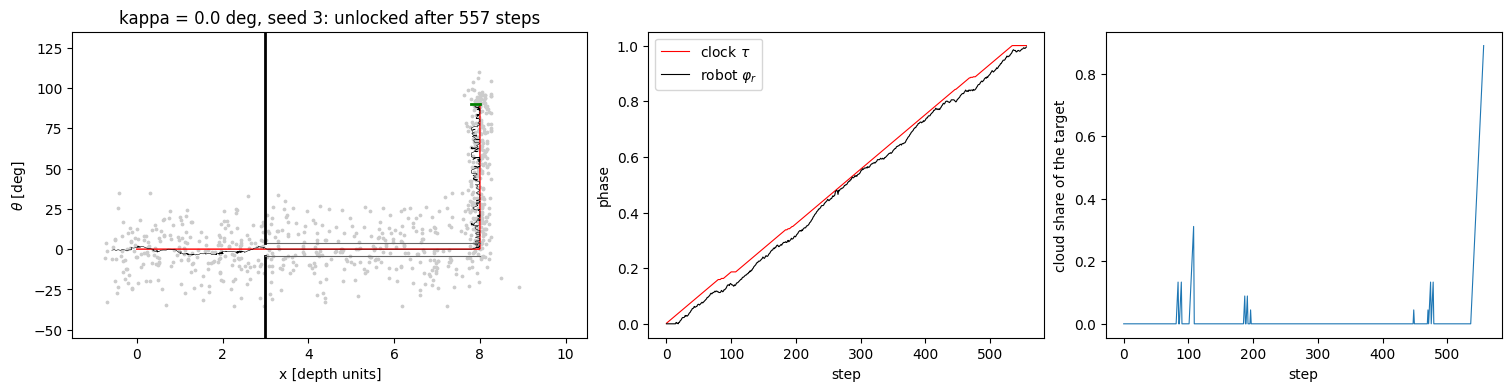

0 entries into the false keyway, 0 step-backs, cloud share above 0 on 8% of steps


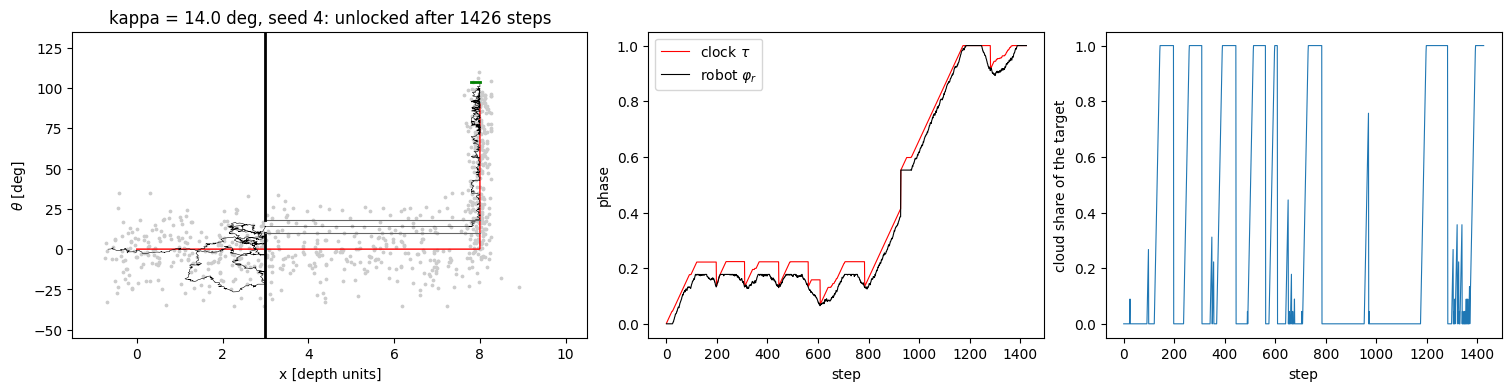

0 entries into the false keyway, 7 step-backs, cloud share above 0 on 47% of steps


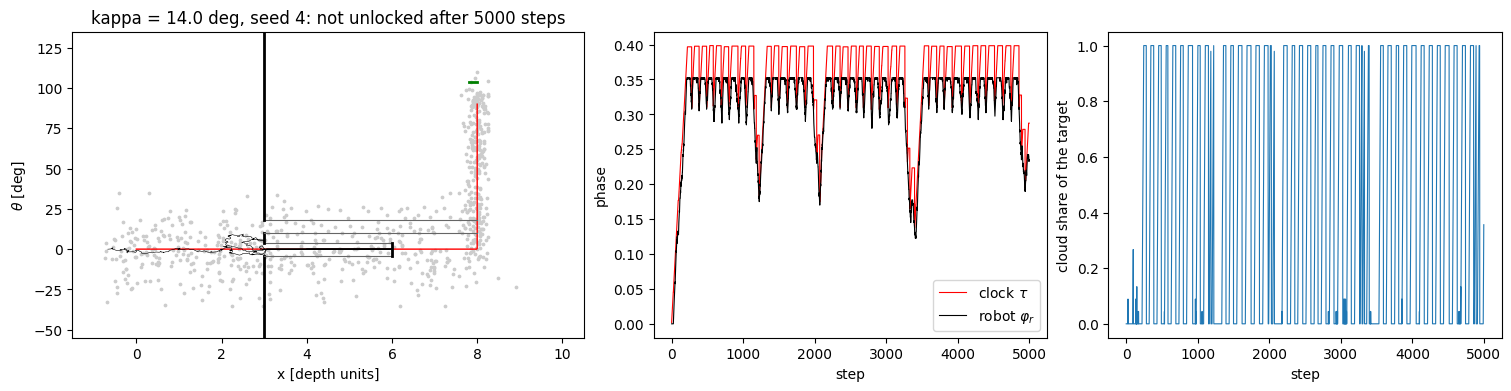

4 entries into the false keyway, 46 step-backs, cloud share above 0 on 55% of steps


In [7]:
def draw_lock(ax, kappa, false_kappa=None):
    """The face with a gap of +-4 deg per keyway; the false one is closed off at FALSE_DEPTH."""
    keyways = sorted([(kappa, DEPTH)] + ([] if false_kappa is None else [(false_kappa, FALSE_DEPTH)]))
    edge = -55
    for angle, depth in keyways:
        lo, hi = angle - 4, angle + 4
        ax.plot([FACE, FACE], [edge, lo], "-k", lw=2)
        ax.plot([FACE, depth], [lo, lo], "-", color="0.4", lw=0.8)
        ax.plot([FACE, depth], [hi, hi], "-", color="0.4", lw=0.8)
        if depth < DEPTH:
            ax.plot([depth, depth], [lo, hi], "-k", lw=2)
        edge = hi
    ax.plot([FACE, FACE], [edge, 135], "-k", lw=2)
    ax.plot([TURN_DEPTH, DEPTH], [kappa + 90, kappa + 90], "-g", lw=2, label="90 deg stop")


def show_run(kappa, seed, false_kappa=None, **flags):
    run = type("Variant", (Run,), flags)(kappa, seed=seed, false_kappa=false_kappa).run()
    log = np.array(run.log)
    fig, (world, phases, share) = plt.subplots(
        1, 3, figsize=(15, 3.8), width_ratios=[1.3, 1, 1], layout="constrained"
    )
    world.scatter(CLOUD[:, 0], CLOUD[:, 1] * THETA_SCALE, s=3, c="0.8")
    world.plot(MASTER[:, 0], MASTER[:, 1] * THETA_SCALE, "-r", lw=1, label="master")
    world.plot(log[:, 0], log[:, 1] * THETA_SCALE, "-k", lw=0.4)
    draw_lock(world, kappa, false_kappa)
    world.set(xlim=(-1.5, 10.5), ylim=(-55, 135), xlabel="x [depth units]", ylabel=r"$\theta$ [deg]")
    phases.plot(log[:, 3], "-r", lw=0.8, label=r"clock $\tau$")
    phases.plot(log[:, 2], "-k", lw=0.8, label=r"robot $\varphi_r$")
    phases.set(xlabel="step", ylabel="phase")
    phases.legend()
    share.plot(log[:, 5], lw=0.8)
    share.set(xlabel="step", ylabel="cloud share of the target")
    world.set_title(
        f"kappa = {kappa} deg, seed {seed}: {'unlocked' if run.done else 'not unlocked'} after {run.n} steps"
    )
    plt.show()
    print(
        f"{run.false_entries} entries into the false keyway, {run.step_backs} step-backs, "
        f"cloud share above 0 on {np.mean(log[:, 5] > 0):.0%} of steps"
    )
    return run


_ = show_run(0.0, seed=3)
_ = show_run(14.0, seed=4)
_ = show_run(14.0, seed=4, false_kappa=0.0)

## 7. Sweep

$\kappa \in \{-20, \dots, 20\}$ with 5 noise seeds, 5000 steps a run: 35 runs on the plain lock, and 30 with the
false keyway at $0°$ ($\kappa = 0°$ left out, where the two keyways coincide).

In [8]:
KAPPAS = [-20, -14, -8, 0, 8, 14, 20]
SEEDS = [3, 4, 5, 6, 7]
OTHER_KAPPAS = [k for k in KAPPAS if k != 0]


def sweep(**flags):
    variant = type("Variant", (Run,), flags)
    plain = [variant(k, seed=s).run() for k in KAPPAS for s in SEEDS]
    false = [variant(k, seed=s, false_kappa=0.0).run() for k in OTHER_KAPPAS for s in SEEDS]
    return (
        f"plain {sum(r.done for r in plain):>2}/35, false keyway {sum(r.done for r in false):>2}/30, "
        f"{np.mean([r.false_entries for r in false]):4.1f} entries and "
        f"{np.mean([r.step_backs for r in false]):4.1f} step-backs a run"
    )


for label, flags in (
    ("clock, step-back", {}),
    ("clock, no step-back", {"step_back": False}),
    ("dwell stall, step-back", {"dwell_stall": True}),
    ("dwell stall, no step-back", {"dwell_stall": True, "step_back": False}),
):
    print(f"{label:>26}: {sweep(**flags)}")

          clock, step-back: plain 30/35, false keyway  2/30,  4.7 entries and 44.5 step-backs a run


       clock, no step-back: plain 23/35, false keyway 19/30,  3.2 entries and  0.0 step-backs a run


    dwell stall, step-back: plain  9/35, false keyway  0/30,  4.3 entries and 53.4 step-backs a run


 dwell stall, no step-back: plain 22/35, false keyway 19/30,  3.5 entries and  0.0 step-backs a run


## 8. Results

| stall measure | step-back | plain lock | false keyway |
|---|---|---|---|
| clock | on | 30/35 | 2/30 |
| clock | off | 23/35 | 19/30 |
| dwell | on | 9/35 | 0/30 |
| dwell | off | 22/35 | 19/30 |

For comparison, the phase notebook's law on the same runs: 25/35 and 16/30.

- **Tracking works.** In free insertion ($\kappa = 0°$) the robot follows the clock to the end in 557 steps, with the
  cloud in the target on 8 % of them. The clock runs at $0.48\, v_{\max}$; that is what the robot reaches.
- **The step-back helps the plain lock and breaks the false keyway.** After a jam at the face it restarts the
  approach from where the robot is: 30/35 against 23/35. In the false keyway it does the same thing, and that is the
  failure: the robot backs off $2\epsilon$, the clock is set back to it with $c = 0$, the target is the master again,
  and the master leads back to the dead end. The third run of Section 6 does this 46 times and never leaves.
- **Without the step-back the false keyway is 19/30**, with either stall measure. The clock stays at the dead
  end, $c$ keeps growing, and the cloud's backward kernel widens until the robot is out past the face.
- **A stall measure that carries over needs no step-back, and is worse with one.** Time already spent at a phase
  is not reset by setting the clock back, so the two fight.
- **Open.** No variant does well on both locks. What the step-back lacks is any memory that this stretch of the
  master was already followed to a stall: it hands the target back to the master unconditionally.